In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


In [2]:

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [3]:
 
df = pd.read_csv("/kaggle/input/datasets/mohamedismal/water-data/Combined_dataset.csv")
 

In [4]:
print("Shape:", df.shape)
df.head()
df.info()
 

Shape: (2827977, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           object 
 1   Area                              object 
 2   Waterbody Type                    object 
 3   Date                              object 
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          object 
dtypes: float64(9), object(5)
memory usage: 302.1+ MB


In [5]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [6]:
df["CCME_Values"].describe()


count    2.827977e+06
mean     8.504668e+01
std      1.764665e+01
min      3.130414e+01
25%      7.715349e+01
50%      9.059609e+01
75%      1.000000e+02
max      1.000000e+02
Name: CCME_Values, dtype: float64

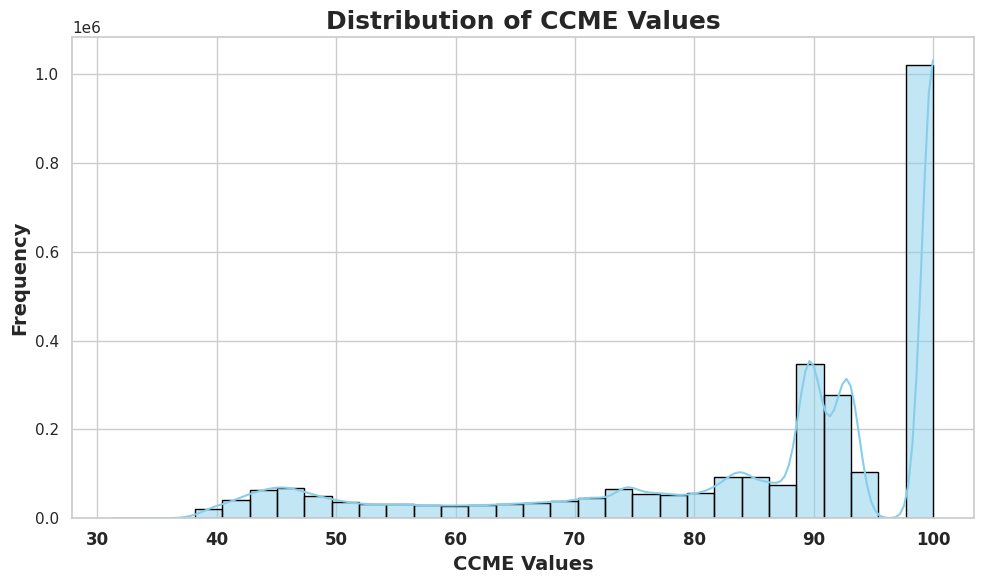

In [7]:

plt.figure(figsize=(10, 6))
sns.histplot(df["CCME_Values"].dropna(), bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of CCME Values", fontsize=18, fontweight="bold")
plt.xlabel("CCME Values", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



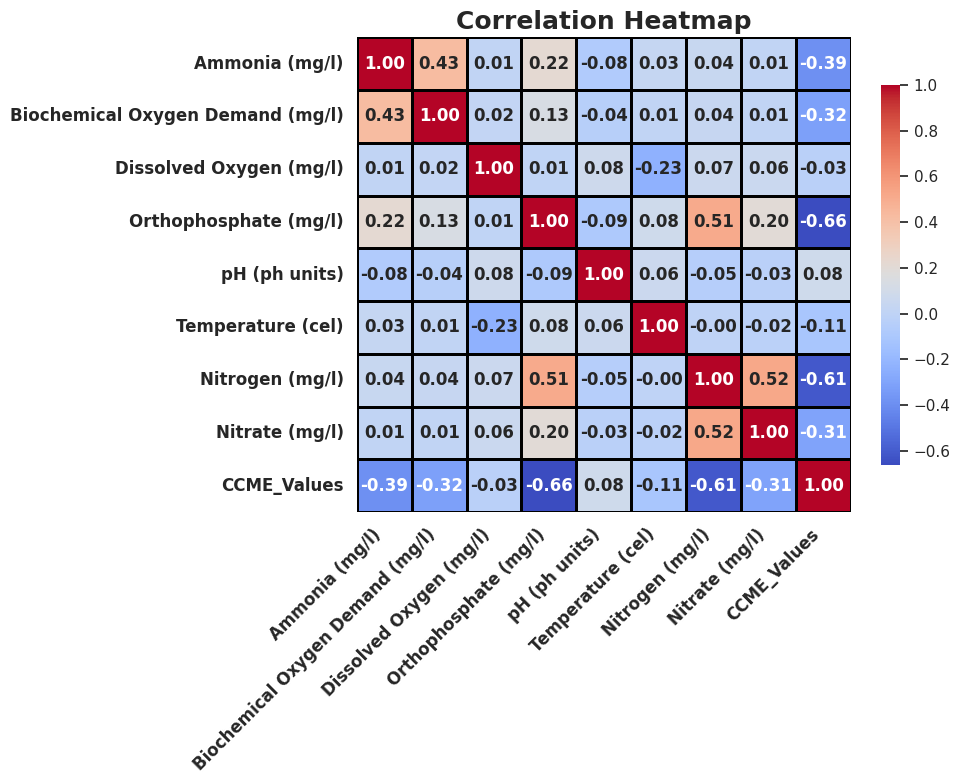

In [8]:
 
# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [9]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [10]:
# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])



Columns after encoding: 23


In [11]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")


Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [12]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_Values"].values.astype(np.float32)
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val   = clean_cols(X_val)
X_test  = clean_cols(X_test)

# ✅ FIX: Use reindex to safely align columns with train set.
# This handles cases where val/test splits are missing certain one-hot
# categories that exist in train (fills missing columns with 0).
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train columns : {X_train.shape[1]}")
print(f"Val   columns : {X_val.shape[1]}  (aligned to train)")
print(f"Test  columns : {X_test.shape[1]}  (aligned to train)")

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")


Train columns : 16
Val   columns : 16  (aligned to train)
Test  columns : 16  (aligned to train)
Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [13]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")


# ── Save sequences to disk ──
import joblib
joblib.dump(
    (X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq),
    "sequences.pkl"
)
print("[✔] sequences.pkl saved.")


Windowing: 100%|██████████| 9005/9005 [00:55<00:00, 161.08area/s]


Train seq: (440536, 8, 16) | Val: (348027, 8, 16) | Test: (359950, 8, 16)
[✔] sequences.pkl saved.


In [14]:
import joblib

 
X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [15]:

X_train_t = torch.FloatTensor(X_train_seq)                        # CPU – DataLoader transfers each batch
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1)           # CPU

X_val_t   = torch.FloatTensor(X_val_seq).to(device)               # GPU – used directly
y_val_t   = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)  # GPU

X_test_t  = torch.FloatTensor(X_test_seq).to(device)              # GPU – used directly
y_test_t  = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device) # GPU

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=(device.type == 'cuda'),     
                           num_workers=0)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Loaders ready.")
print(f"  Train batches : {len(train_loader)} | X_train_t device: {X_train_t.device}")
print(f"  Val   batches : {len(val_loader)}   | X_val_t   device: {X_val_t.device}")
print(f"  Test  batches : {len(test_loader)}  | X_test_t  device: {X_test_t.device}")


Loaders ready.
  Train batches : 6884 | X_train_t device: cpu
  Val   batches : 5438   | X_val_t   device: cuda:0
  Test  batches : 5625  | X_test_t  device: cuda:0


In [16]:
# ─────────────────────────────────────────────
# SECTION 7: Model Architecture
#   CNN-BiLSTM-SA (Self-Attention)
#   Paper: Study on short-term total hardness prediction
#          of water quality based on CNN-BiLSTM-SA model
# ─────────────────────────────────────────────

class SelfAttentionLayer(nn.Module):
    """Self-Attention layer (Q, K, V projections)."""
    def __init__(self, output_dim):
        super().__init__()
        self.output_dim = output_dim
        self.W_q = nn.Linear(output_dim, output_dim)
        self.W_k = nn.Linear(output_dim, output_dim)
        self.W_v = nn.Linear(output_dim, output_dim)
        self.scale = output_dim ** 0.5

    def forward(self, x):
        # x: [B, T, output_dim]
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # [B, T, T]
        weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(weights, V)                           # [B, T, D]
        self.last_attn_weights = weights.detach()
        return context


class CNNBiLSTMSA(nn.Module):
    """
    CNN-BiLSTM-SA for Water Quality Regression (CCME prediction).

    Architecture (faithful to paper):
        Input
        → BiLSTM-1 (hidden=32, return_sequences=True) + Dropout(0.05)
        → SelfAttention(output_dim=50)
        → BiLSTM-2 (hidden=64)
        → Linear(1)

    Note: The original paper uses Keras Conv1D+MaxPool before BiLSTM,
    but the official code feeds the raw sequence directly to BiLSTM.
    We follow the official code exactly.
    CNN layers are kept as an optional wrapper for completeness.
    """
    def __init__(self, input_dim, hidden1=32, hidden2=64,
                 attn_dim=50, dropout=0.05):
        super().__init__()
        self.input_dim = input_dim

        # ── CNN block (optional front-end as in paper Figure) ──
        # Conv1D(64, kernel=2) → MaxPool(2) → Dropout(0.1)
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=input_dim, out_channels=64,
                      kernel_size=2, padding=1),   # keep length ≥ T
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=1, padding=1),  # stride=1 to keep T
            nn.Dropout(0.1)
        )
        cnn_out_channels = 64

        # ── BiLSTM-1 (return_sequences=True) ──
        self.bilstm1 = nn.LSTM(
            input_size=cnn_out_channels,
            hidden_size=hidden1,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.dropout1 = nn.Dropout(dropout)

        # ── Self-Attention ──
        self.self_attn = SelfAttentionLayer(output_dim=hidden1 * 2)  # 64

        # ── BiLSTM-2 (return last hidden) ──
        self.bilstm2 = nn.LSTM(
            input_size=hidden1 * 2,
            hidden_size=hidden2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # ── Regression head ──
        self.fc = nn.Linear(hidden2 * 2, 1)

        # For XAI compatibility (attention weights)
        self.last_attn_weights = None

    def forward(self, x):
        # x: [B, T, F]

        # CNN block: Conv1D expects [B, C, L]
        x_cnn = self.cnn(x.permute(0, 2, 1))   # [B, 64, T']
        x_cnn = x_cnn.permute(0, 2, 1)          # [B, T', 64]

        # BiLSTM-1
        out1, _ = self.bilstm1(x_cnn)            # [B, T', 64]
        out1    = self.dropout1(out1)

        # Self-Attention
        attn_out = self.self_attn(out1)           # [B, T', 64]
        self.last_attn_weights = self.self_attn.last_attn_weights  # [B, T', T']

        # BiLSTM-2 → take last time step
        out2, _ = self.bilstm2(attn_out)          # [B, T', 128]
        out2    = out2[:, -1, :]                  # [B, 128]

        # Output
        return self.fc(out2)                      # [B, 1]


input_size = X_train_seq.shape[2]

model = CNNBiLSTMSA(
    input_dim=input_size,
    hidden1=32,
    hidden2=64,
    attn_dim=50,
    dropout=0.05
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: CNN-BiLSTM-SA")
print(f"Parameters: {num_params:,}")
print(f"Task: Regression → predicting CCME_Values (0-100 continuous)")
print(model)



Model: CNN-BiLSTM-SA
Parameters: 106,369
Task: Regression → predicting CCME_Values (0-100 continuous)
CNNBiLSTMSA(
  (cnn): Sequential(
    (0): Conv1d(16, 64, kernel_size=(2,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.1, inplace=False)
  )
  (bilstm1): LSTM(64, 32, batch_first=True, bidirectional=True)
  (dropout1): Dropout(p=0.05, inplace=False)
  (self_attn): SelfAttentionLayer(
    (W_q): Linear(in_features=64, out_features=64, bias=True)
    (W_k): Linear(in_features=64, out_features=64, bias=True)
    (W_v): Linear(in_features=64, out_features=64, bias=True)
  )
  (bilstm2): LSTM(64, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [17]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-5
)

# Learning rate scheduler (OneCycleLR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=100,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Training hyperparameters
NUM_EPOCHS    = 100
PATIENCE      = 6
MIN_DELTA     = 0.01
GRADIENT_CLIP = 1.0

print(f"Criterion    : {criterion.__class__.__name__}")
print(f"Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)")
print(f"Scheduler    : OneCycleLR  (max_lr=1e-3, epochs={NUM_EPOCHS})")
print(f"Early Stop   : patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Gradient Clip: {GRADIENT_CLIP}")


Criterion    : MSELoss
Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)
Scheduler    : OneCycleLR  (max_lr=1e-3, epochs=100)
Early Stop   : patience=6, min_delta=0.01
Gradient Clip: 1.0


In [18]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_loss, path=CHECKPOINT_PATH,
                    train_losses=None, val_losses=None, learning_rates=None):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, best validation score, AND training history lists.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path   = path + ".tmp"
    checkpoint = {
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "best_val_loss":   best_val_loss,
        # ── Training history (for learning curves) ──
        "train_losses":    train_losses   if train_losses   is not None else [],
        "val_losses":      val_losses     if val_losses     is not None else [],
        "learning_rates":  learning_rates if learning_rates is not None else [],
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state including history lists.
    Returns (start_epoch, best_val_loss, train_losses, val_losses, learning_rates).
    If checkpoint does not exist → returns defaults to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, float('inf'), [], [], []

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch    = ckpt["epoch"] + 1       # resume AFTER the saved epoch
    best_val_loss  = ckpt["best_val_loss"]
    train_losses   = ckpt.get("train_losses",   [])
    val_losses     = ckpt.get("val_losses",     [])
    learning_rates = ckpt.get("learning_rates", [])

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val MSE so far: {best_val_loss:.4f} | "
          f"History loaded: {len(train_losses)} epochs")
    return start_epoch, best_val_loss, train_losses, val_losses, learning_rates


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [19]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop (Regression)
# ─────────────────────────────────────────────

start_epoch, best_val_loss, train_losses, val_losses, learning_rates = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None

print("\n" + "="*80)
print(f"{'Epoch':<8}|{'Train Loss (MSE)':<18}|{'Val Loss (MSE)':<18}|{'LR':<10}")
print("-" * 80)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:
         
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * batch_y.size(0)
        tr_total += batch_y.size(0)
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()

    tr_loss /= tr_total
    train_losses.append(tr_loss)

    model.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # val tensors already on device — no .to(device) needed
            logits = model(batch_x)
            loss   = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            v_total += batch_y.size(0)

    v_loss /= v_total
    val_losses.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<18.4f}|{v_loss:<18.4f}|{current_lr:<10.6f}")

    # ── Save latest checkpoint WITH full history ──
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                    path=CHECKPOINT_PATH,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    learning_rates=learning_rates)

    if v_loss < best_val_loss - MIN_DELTA:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                        path=BEST_MODEL_PATH,
                        train_losses=train_losses,
                        val_losses=val_losses,
                        learning_rates=learning_rates)
        print(f"   ✔ Best model saved! (Val Loss: {v_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*80)
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
checkpoint = torch.load(BEST_MODEL_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state"])


[Checkpoint] No checkpoint found – starting from scratch.

Epoch   |Train Loss (MSE)  |Val Loss (MSE)    |LR        
--------------------------------------------------------------------------------


1       |4554.7555         |2103.3014         |0.000063  
   ✔ Best model saved! (Val Loss: 2103.3014)


2       |687.1630          |12.1123           |0.000132  
   ✔ Best model saved! (Val Loss: 12.1123)


3       |9.5979            |5.9100            |0.000238  
   ✔ Best model saved! (Val Loss: 5.9100)


4       |5.7694            |3.6817            |0.000372  
   ✔ Best model saved! (Val Loss: 3.6817)


...

15      |1.5039            |1.7422            |0.000992  


16      |1.4337            |1.7288            |0.000989  


17      |1.3682            |1.6100            |0.000985  


18      |1.3188            |1.9988            |0.000981  

⚡ Early stopping at epoch 18
Best Val Loss: 1.3346
Total epochs trained: 18


<All keys matched successfully>

In [20]:

# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_total = 0.0, 0
t_preds, t_targets = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item() * batch_y.size(0)
        
        t_total += batch_y.size(0)
        t_preds.extend(out.cpu().numpy().flatten())
        t_targets.extend(batch_y.cpu().numpy().flatten())

t_preds = np.array(t_preds)
t_targets = np.array(t_targets)

test_mse = mean_squared_error(t_targets, t_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(t_targets, t_preds)
test_r2 = r2_score(t_targets, t_preds)

print(f"\nTest MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")




Test MSE:  1.4059
Test RMSE: 1.1857
Test MAE:  0.4770
Test R2:   0.9948


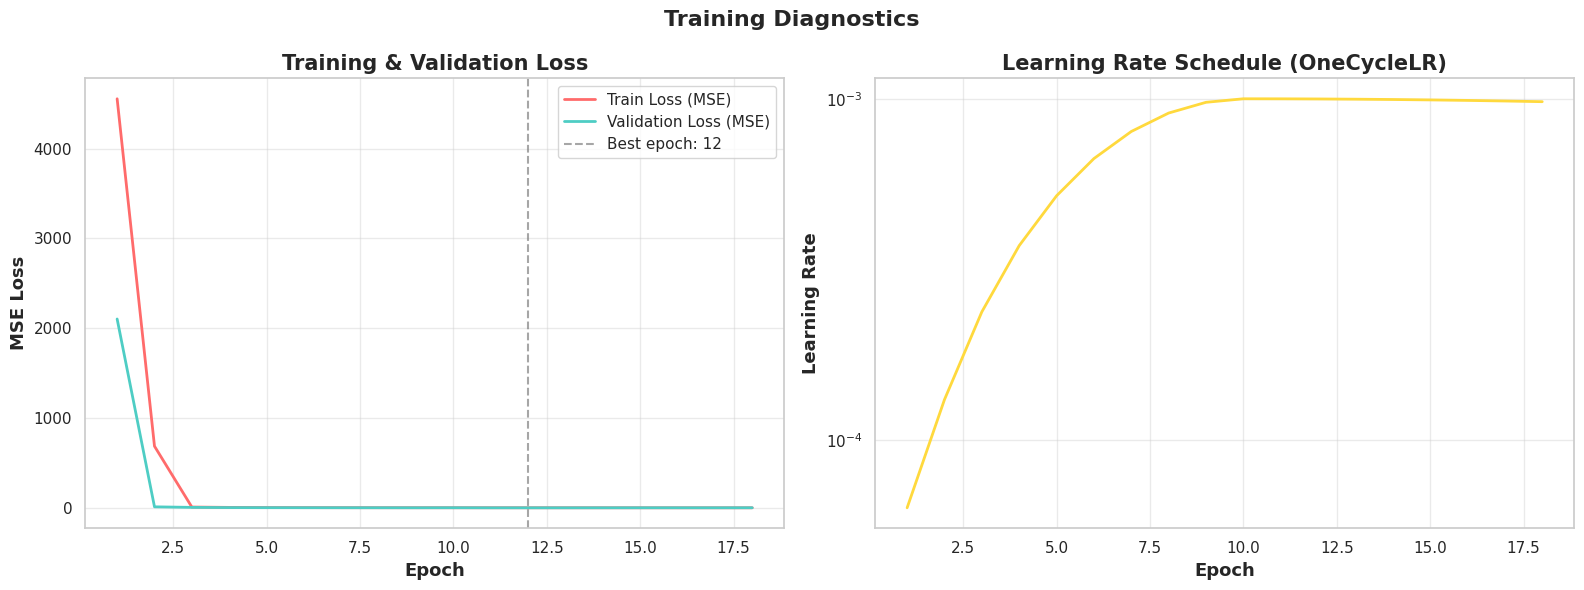

Best Val Loss: 1.3346 at epoch 12
Final Train Loss: 1.3188
Final Val Loss:   1.9988


In [21]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
# Note: train_losses / val_losses / learning_rates are either from the
# current run OR loaded from checkpoint — both cases are handled.

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Train vs Val Loss ──
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)',
             color='#FF6B6B', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)',
             color='#4ECDC4', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# Mark best epoch (lowest val loss)
best_epoch = int(val_losses.index(min(val_losses))) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].legend(fontsize=11)

# ── Plot 2: Learning Rate Schedule ──
axes[1].plot(epochs_range, learning_rates, color='#FFD93D', linewidth=2)
axes[1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Diagnostics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")


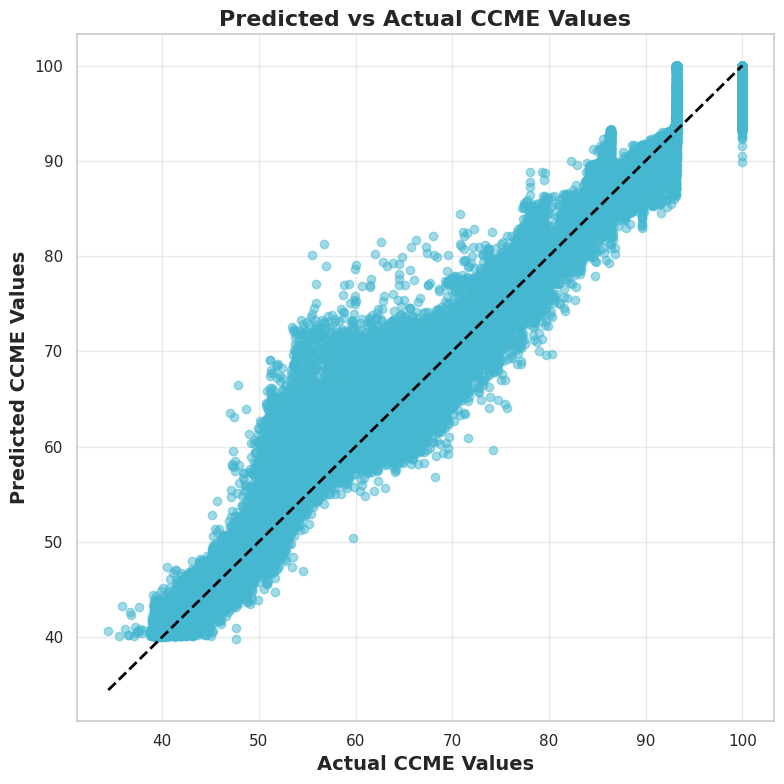

In [22]:

# ─────────────────────────────────────────────
# SECTION 12: Parity Plot (Predicted vs Actual)
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.scatter(t_targets, t_preds, alpha=0.5, color='#45B7D1')
plt.plot([min(t_targets), max(t_targets)], [min(t_targets), max(t_targets)], color='black', linestyle='--', linewidth=2)
plt.title('Predicted vs Actual CCME Values', fontsize=16, fontweight='bold')
plt.xlabel('Actual CCME Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted CCME Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=300)
plt.show()



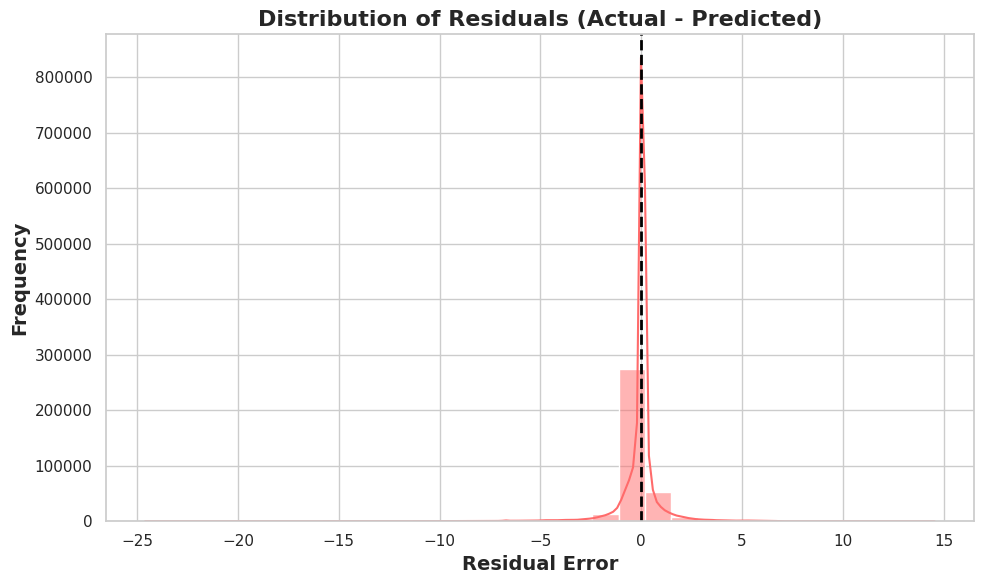

In [23]:

# ─────────────────────────────────────────────
# SECTION 13: Residual Distribution Plot
# ─────────────────────────────────────────────
residuals = t_targets - t_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="#FF6B6B")
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()




  REGRESSION METRICS — CCME_Values Prediction
  Metric  Value                                      Description
     MSE 1.4059   Mean Squared Error – average squared deviation
    RMSE 1.1857 Root Mean Squared Error – in original CCME units
     MAE 0.4770 Mean Absolute Error – average absolute deviation
R² Score 0.9948 Coefficient of Determination – 1.0 = perfect fit


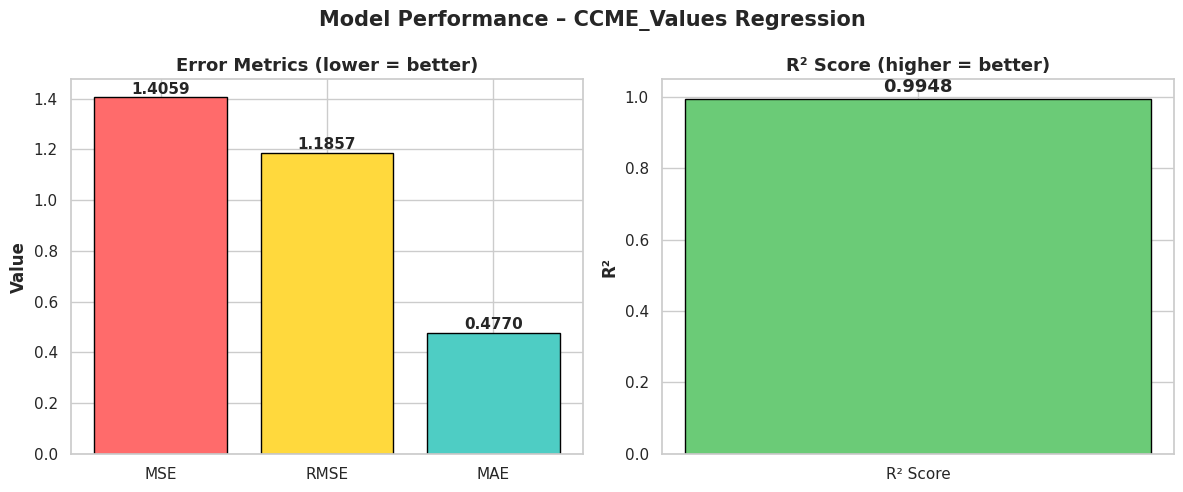

In [24]:
# ─────────────────────────────────────────────
# SECTION 14: Regression Metrics Summary Table
# ─────────────────────────────────────────────
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Value':  [test_mse, test_rmse, test_mae, test_r2],
    'Description': [
        'Mean Squared Error – average squared deviation',
        'Root Mean Squared Error – in original CCME units',
        'Mean Absolute Error – average absolute deviation',
        'Coefficient of Determination – 1.0 = perfect fit'
    ]
})
metrics_df['Value'] = metrics_df['Value'].round(4)

print("\n" + "="*60)
print("  REGRESSION METRICS — CCME_Values Prediction")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

# Visual bar chart of error metrics (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

error_names  = ['MSE', 'RMSE', 'MAE']
error_values = [test_mse, test_rmse, test_mae]
axes[0].bar(error_names, error_values, color=['#FF6B6B', '#FFD93D', '#4ECDC4'],
            edgecolor='black')
axes[0].set_title('Error Metrics (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
for i, v in enumerate(error_values):
    axes[0].text(i, v + 0.01 * max(error_values), f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['R² Score'], [test_r2], color='#6BCB77', edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('R² Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=12, fontweight='bold')
axes[1].text(0, test_r2 + 0.02, f'{test_r2:.4f}', ha='center',
             fontsize=13, fontweight='bold')

plt.suptitle('Model Performance – CCME_Values Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



[XAI] Extracting Self-Attention Heatmaps...


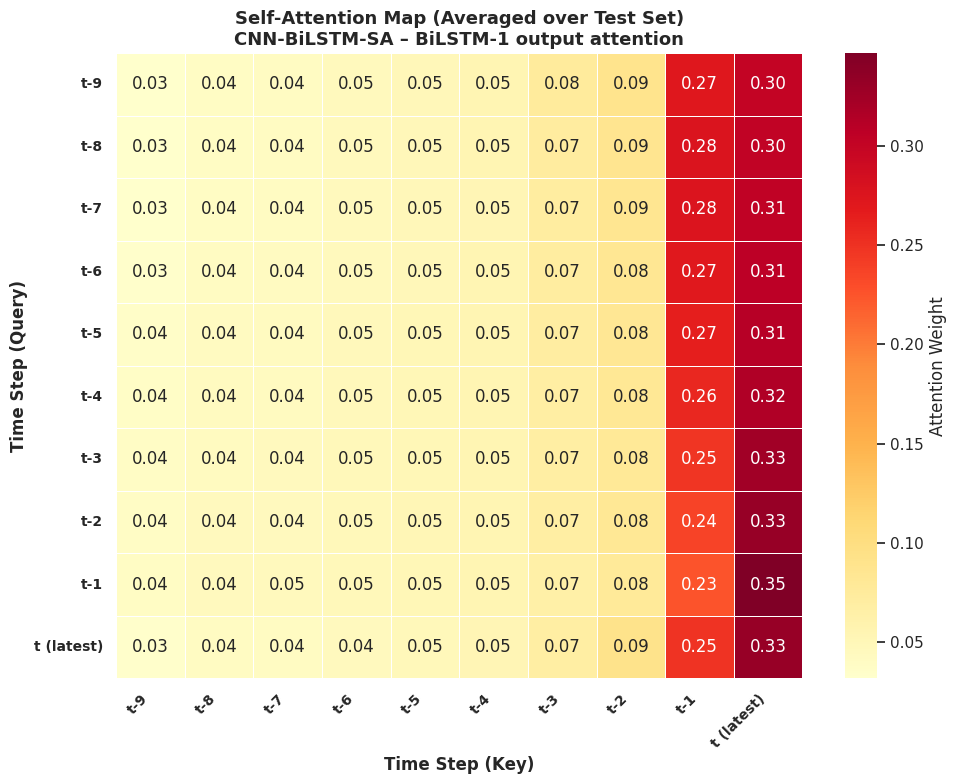

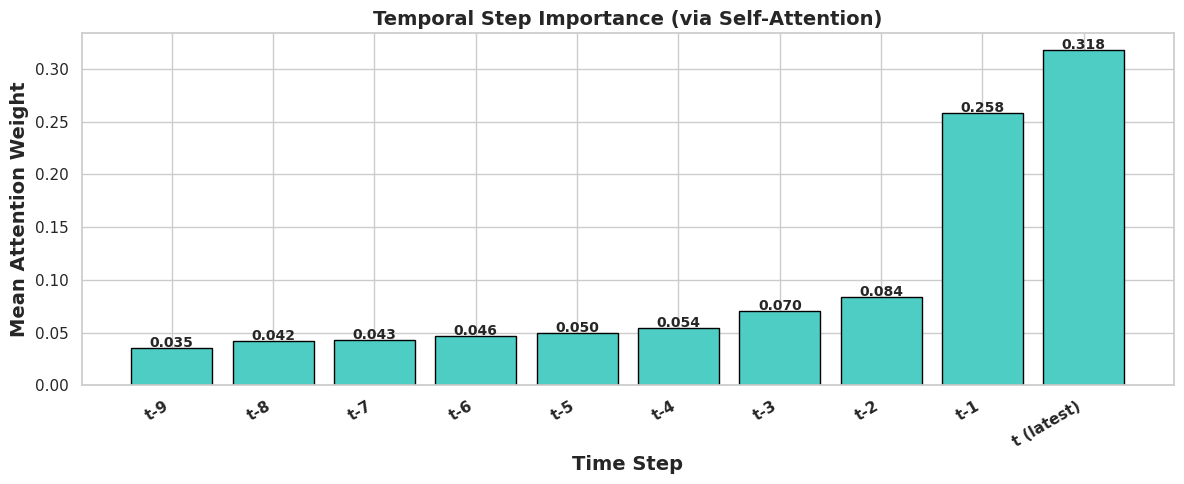

In [25]:
# ─────────────────────────────────────────────
# SECTION 15: XAI – Self-Attention Heatmap
#   CNN-BiLSTM-SA stores [B, T', T'] self-attention weights
# ─────────────────────────────────────────────
print("\n[XAI] Extracting Self-Attention Heatmaps...")
feature_names = X_train.columns.tolist()
model.eval()

attn_maps_all = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        _ = model(batch_x)
        attn_maps_all.append(model.last_attn_weights.cpu().numpy())  # [B, T', T']

attn_maps_all = np.concatenate(attn_maps_all, axis=0)  # [N, T', T']
mean_attn = attn_maps_all.mean(axis=0)                  # [T', T']

T_prime = mean_attn.shape[0]
time_step_labels = [f"t-{T_prime - 1 - i}" if i < T_prime - 1 else "t (latest)"
                    for i in range(T_prime)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mean_attn, cmap="YlOrRd", annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Attention Weight"},
            xticklabels=time_step_labels,
            yticklabels=time_step_labels)
ax.set_title("Self-Attention Map (Averaged over Test Set)\n"
             "CNN-BiLSTM-SA – BiLSTM-1 output attention",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time Step (Key)", fontsize=12, fontweight="bold")
ax.set_ylabel("Time Step (Query)", fontsize=12, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10, fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

time_importance = mean_attn.mean(axis=0)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(time_step_labels, time_importance, color="#4ECDC4", edgecolor="black")
for bar, val in zip(bars, time_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Time Step", fontsize=14, fontweight="bold")
ax.set_ylabel("Mean Attention Weight", fontsize=14, fontweight="bold")
ax.set_title("Temporal Step Importance (via Self-Attention)", fontsize=14, fontweight="bold")
ax.set_xticklabels(time_step_labels, rotation=30, ha="right", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# End of notebook — CNN-BiLSTM-SA Regression on CCME_Values
